In [1]:
#Setup & Imports
import warnings, io
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
)

# Models & explainability
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Gradient boosting (optional; comment if not installed)
from xgboost import XGBClassifier

# Persistence
import joblib

# Reproducibility & display
RANDOM_SEED = 42
pd.set_option('display.max_columns', 200)
plt.rcParams['figure.figsize'] = (6, 4)


In [2]:
# Load Data & Create Target

from google.colab import drive
drive.mount('/content/drive')

# Change the path below to where your CSV lives in Drive
DATA_PATH = '/content/drive/MyDrive/42048/ecommerce_cart_abandonment_5k.csv'
df = pd.read_csv(DATA_PATH)

# --- Basic sanity checks ---
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

print("\nPreview (top 5):")
display(df.head())

print("\nInfo:")
print(df.info())

print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

# --- Standardize column names (optional but tidy) ---
df.columns = [c.strip() for c in df.columns]

# --- Coerce common boolean-like columns if present ---
bool_like = ['HasCouponApplied', 'IsReturningCustomer']
for col in bool_like:
    if col in df.columns:
        # Handles True/False, 'true'/'false', 0/1, etc.
        df[col] = df[col].astype(str).str.strip().str.lower().map(
            {'true': True, 'false': False, '1': True, '0': False}
        ).fillna(df[col]).astype('category')

# --- Create binary target: Abandoned (1) vs No Abandonment (0) ---
if 'AbandonmentReason' in df.columns:
    df['Abandoned'] = (df['AbandonmentReason'] != 'No Abandonment').astype(int)
else:
    raise ValueError("Expected column 'AbandonmentReason' not found in the dataset.")

# --- Quick class balance & reason distribution ---
print("\nClass balance (Abandoned=1):")
print(df['Abandoned'].value_counts(normalize=True).rename({0:'No Abandonment',1:'Abandoned'}).round(4))

if 'AbandonmentReason' in df.columns:
    print("\nAbandonmentReason counts:")
    print(df['AbandonmentReason'].value_counts())

# --- identify feature groups for later steps ---
ID_COLS = [c for c in ['UserID', 'SessionID'] if c in df.columns]
TARGET = 'Abandoned'
DROP_COLS = ID_COLS + ['AbandonmentReason']  # keep reason for EDA only

# Split feature matrix and target (will be reused in the next step)
X = df.drop(columns=[*DROP_COLS, TARGET], errors='ignore')
y = df[TARGET]

print("\nFeature matrix shape:", X.shape, " | Target shape:", y.shape)
print("\nCategorical columns:", X.select_dtypes(include=['object','category','bool']).columns.tolist())
print("Numeric columns:", X.select_dtypes(include=['number']).columns.tolist())

Mounted at /content/drive
Shape: (5000, 12)

Columns: ['UserID', 'SessionID', 'BrowserType', 'OperatingSystem', 'DeviceType', 'NumItemsInCart', 'CartTotalAmount', 'TimeSpentOnSiteMinutes', 'HasCouponApplied', 'IsReturningCustomer', 'LastPageViewedCategory', 'AbandonmentReason']

Preview (top 5):


,UserID,SessionID,BrowserType,OperatingSystem,DeviceType,NumItemsInCart,CartTotalAmount,TimeSpentOnSiteMinutes,HasCouponApplied,IsReturningCustomer,LastPageViewedCategory,AbandonmentReason
0,8986,311935,Edge,MacOS,Tablet,2,87.96,7.39,False,True,Clothing,Found Better Price
1,1937,207006,Opera,MacOS,Desktop,1,120.00,11.37,False,False,Beauty,Payment Issues
2,3194,779500,Edge,iOS,Desktop,6,150.12,6.80,True,False,Electronics,Found Better Price
3,5125,980665,Opera,iOS,Mobile,3,88.20,7.52,True,True,Electronics,Distraction
4,7250,595333,Edge,Linux,Tablet,4,64.19,3.75,True,False,Books,High Shipping Cost



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   UserID                  5000 non-null   int64  
 1   SessionID               5000 non-null   int64  
 2   BrowserType             5000 non-null   object 
 3   OperatingSystem         5000 non-null   object 
 4   DeviceType              5000 non-null   object 
 5   NumItemsInCart          5000 non-null   int64  
 6   CartTotalAmount         5000 non-null   float64
 7   TimeSpentOnSiteMinutes  5000 non-null   float64
 8   HasCouponApplied        5000 non-null   bool   
 9   IsReturningCustomer     5000 non-null   bool   
 10  LastPageViewedCategory  5000 non-null   object 
 11  AbandonmentReason       5000 non-null   object 
dtypes: bool(2), float64(2), int64(3), object(5)
memory usage: 400.5+ KB
None

Missing values per column:
UserID                    0
SessionID 

Class balance (%):
Abandoned
Abandoned         69.98
No Abandonment    30.02
Name: proportion, dtype: float64

AbandonmentReason distribution:
AbandonmentReason
No Abandonment        1501
High Shipping Cost    1274
Found Better Price     942
Payment Issues         749
Distraction            534
Name: count, dtype: int64


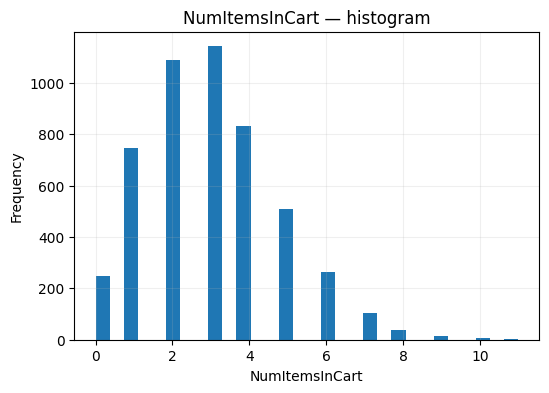

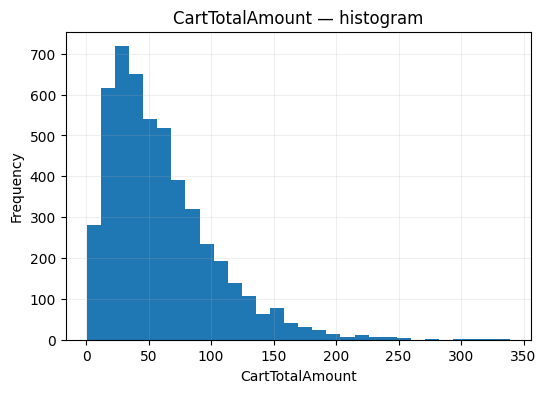

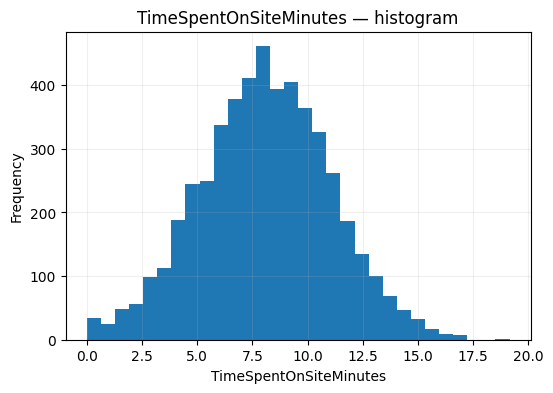

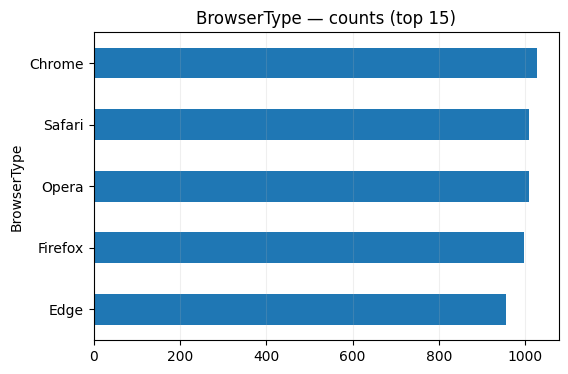

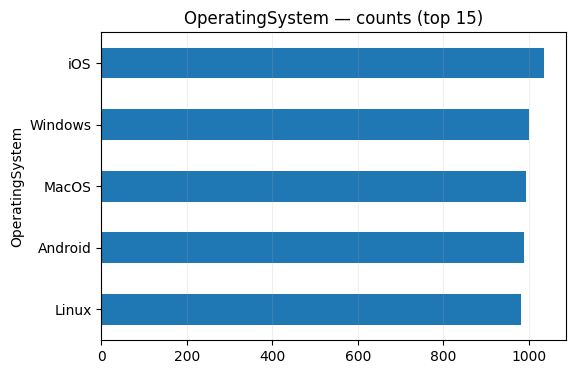

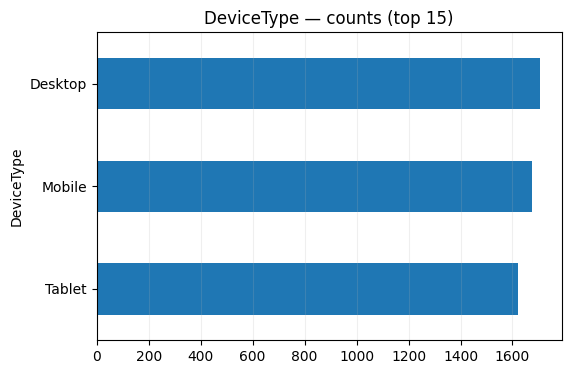

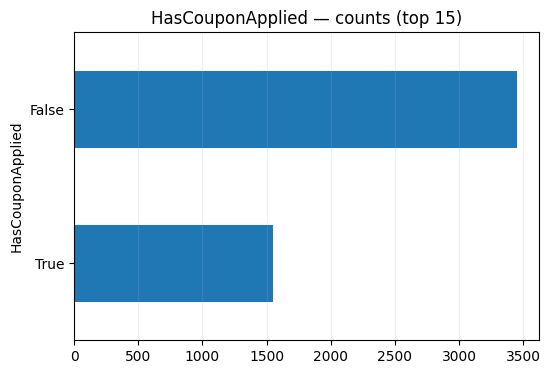

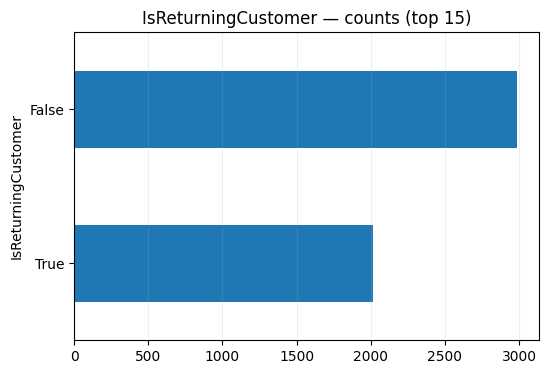

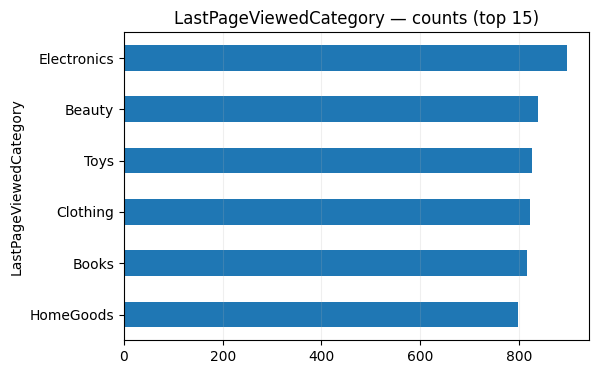

Abandoned,No Abandonment %,Abandoned %
BrowserType,,
Edge,27.899687,72.100313
Firefox,28.757515,71.242485
Opera,30.227948,69.772052
Chrome,30.574489,69.425511
Safari,32.507433,67.492567


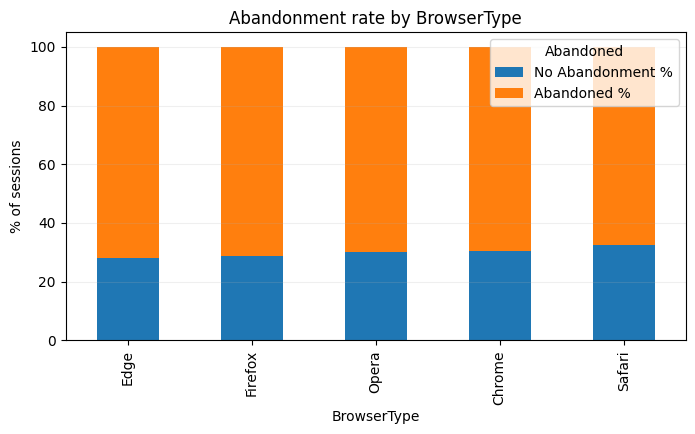

Abandoned,No Abandonment %,Abandoned %
OperatingSystem,,
Windows,27.900000,72.100000
MacOS,29.577465,70.422535
iOS,29.922780,70.077220
Android,30.738119,69.261881
Linux,32.008155,67.991845


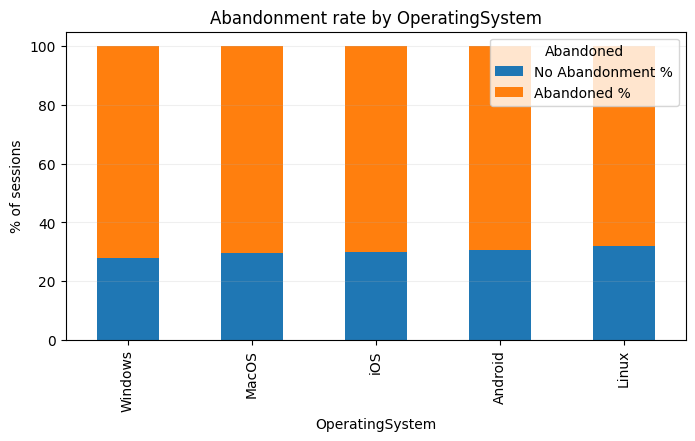

Abandoned,No Abandonment %,Abandoned %
DeviceType,,
Desktop,29.166667,70.833333
Mobile,29.415274,70.584726
Tablet,31.543210,68.456790


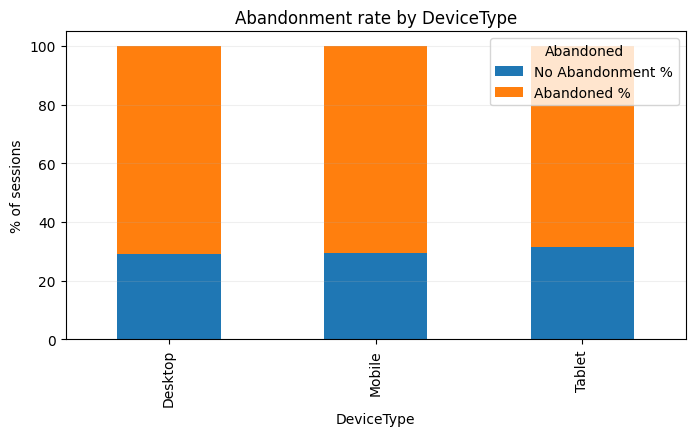

Abandoned,No Abandonment %,Abandoned %
LastPageViewedCategory,,
Books,27.662179,72.337821
Electronics,28.762542,71.237458
Beauty,29.952267,70.047733
Toys,30.108827,69.891173
Clothing,31.630170,68.369830
HomeGoods,32.165207,67.834793


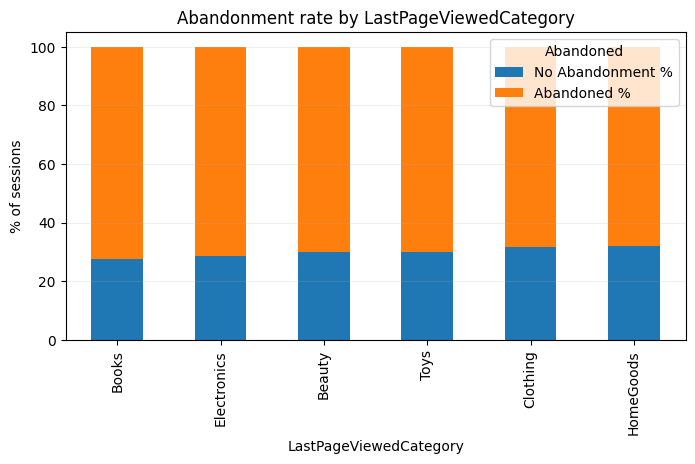

Abandoned,No Abandonment %,Abandoned %
HasCouponApplied,,
False,29.634994,70.365006
True,30.878553,69.121447


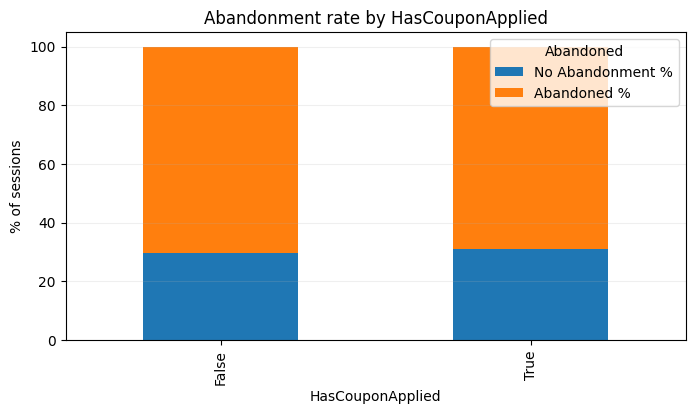

Abandoned,No Abandonment %,Abandoned %
IsReturningCustomer,,
False,28.93503,71.06497
True,31.62860,68.37140


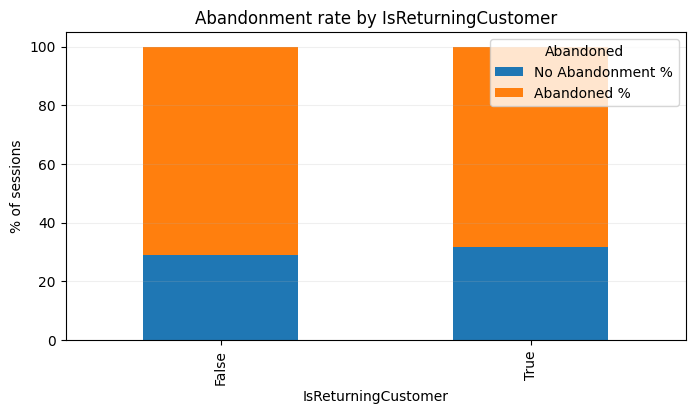

,NumItemsInCart,CartTotalAmount,TimeSpentOnSiteMinutes,Abandoned
NumItemsInCart,1.00,0.00,-0.04,0.01
CartTotalAmount,0.00,1.00,0.02,0.00
TimeSpentOnSiteMinutes,-0.04,0.02,1.00,0.00
Abandoned,0.01,0.00,0.00,1.00


In [3]:
# EDA (quick visuals + summary tables)

# --- high-level class balance
print("Class balance (%):")
print((df['Abandoned'].value_counts(normalize=True) * 100).rename({0:'No Abandonment', 1:'Abandoned'}).round(2))

# --- abandonment reason distribution (if present)
if 'AbandonmentReason' in df.columns:
    print("\nAbandonmentReason distribution:")
    print(df['AbandonmentReason'].value_counts())

# --- helper plotters
def plot_hist(series, bins=30, title=None, xlabel=None):
    series.dropna().plot(kind='hist', bins=bins)
    plt.title(title or series.name)
    plt.xlabel(xlabel or series.name)
    plt.grid(True, alpha=0.2)
    plt.show()

def plot_barh_counts(series, top_n=15, title=None):
    series.value_counts().head(top_n).sort_values().plot(kind='barh')
    plt.title(title or f"{series.name} (top {top_n})")
    plt.grid(True, axis='x', alpha=0.2)
    plt.show()

def stacked_rate_by_cat(col):
    tab = pd.crosstab(df[col], df['Abandoned'], normalize='index')*100
    tab = tab.rename(columns={0:'No Abandonment %', 1:'Abandoned %'}).sort_values('Abandoned %', ascending=False)
    display(tab.head(15))
    tab[['No Abandonment %','Abandoned %']].plot(kind='bar', stacked=True, figsize=(8,4))
    plt.title(f"Abandonment rate by {col}")
    plt.ylabel('% of sessions')
    plt.grid(True, axis='y', alpha=0.2)
    plt.show()

# --- numeric distributions
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
for c in numeric_cols:
    plot_hist(df[c], bins=30, title=f"{c} — histogram")

# --- categorical distributions
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()
for c in cat_cols:
    plot_barh_counts(df[c], title=f"{c} — counts (top 15)")

# --- abandonment rate by key categoricals
for c in [col for col in ['BrowserType','OperatingSystem','DeviceType','LastPageViewedCategory',
                          'HasCouponApplied','IsReturningCustomer'] if col in df.columns]:
    stacked_rate_by_cat(c)

# --- numeric correlation (quick view)
if len(numeric_cols) > 1:
    corr = df[numeric_cols + ['Abandoned']].corr()
    display(corr.round(2))


In [4]:
# Train/Test split + preprocessing (impute + OHE + scale)
from sklearn.pipeline import make_pipeline

# Rebuild feature groups (in case Step 2 edits)
ID_COLS = [c for c in ['UserID','SessionID'] if c in df.columns]
TARGET = 'Abandoned'
DROP_COLS = ID_COLS + ['AbandonmentReason']

X = df.drop(columns=[*DROP_COLS, TARGET], errors='ignore')
y = df[TARGET]

cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

# --- numeric pipeline
num_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# --- categorical pipeline (with compatibility fix)
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)         # fallback for older versions

cat_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', ohe)
])

# --- combine
preprocess = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols),
    ],
    remainder='drop'
)

# --- split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("y_train balance:", y_train.value_counts(normalize=True).round(3).to_dict())


Train shape: (4000, 9) | Test shape: (1000, 9)
y_train balance: {1: 0.7, 0: 0.3}


{'model': 'DummyMostFreq', 'threshold': 0.5, 'accuracy': 0.7, 'precision': 0.7, 'recall': 1.0, 'f1': 0.8235294117647058}
{'model': 'DummyStratified', 'threshold': 0.5, 'accuracy': 0.608, 'precision': 0.7162921348314607, 'recall': 0.7285714285714285, 'f1': 0.7223796033994334, 'roc_auc': np.float64(0.5276190476190477)}


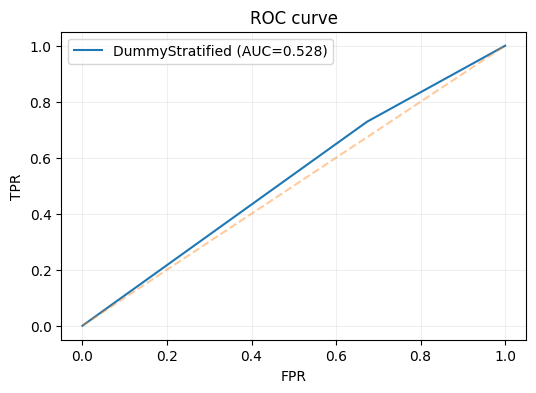

In [5]:
#  — Helpers (metrics/plots) + baseline models

def evaluate_clf(name, pipe, X_test, y_test, threshold=0.5, return_proba=True, verbose=True):
    """
    Evaluates a fitted pipeline 'pipe' that supports predict_proba on X_test.
    """
    proba = pipe.predict_proba(X_test)[:, 1] if return_proba else None
    y_pred = (proba >= threshold).astype(int) if return_proba else pipe.predict(X_test)

    metrics = {
        "model": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }
    if return_proba:
        metrics["roc_auc"] = roc_auc_score(y_test, proba)
    if verbose:
        print(metrics)
    return metrics, proba, y_pred

def plot_roc_pr(name, y_test, proba):
    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')
    plt.plot([0,1],[0,1],'--', alpha=0.4)
    plt.title('ROC curve')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.grid(True, alpha=0.2)
    plt.legend(); plt.show()

    # PR (sklearn returns PR differently; we can easily add if needed)
    # Skipping explicit PR plot to keep cell light.

def sweep_thresholds(y_true, proba, metric='f1'):
    ts = np.linspace(0.1, 0.9, 81)
    rows = []
    for t in ts:
        y_hat = (proba >= t).astype(int)
        rows.append({
            "threshold": t,
            "accuracy": accuracy_score(y_true, y_hat),
            "precision": precision_score(y_true, y_hat, zero_division=0),
            "recall": recall_score(y_true, y_hat, zero_division=0),
            "f1": f1_score(y_true, y_hat, zero_division=0),
        })
    thr_df = pd.DataFrame(rows)
    best = thr_df.sort_values(metric, ascending=False).iloc[0]
    return thr_df, float(best['threshold']), best.to_dict()

# --- Baselines (most_frequent & stratified)
from sklearn.dummy import DummyClassifier

baseline_major = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', DummyClassifier(strategy='most_frequent'))
])
baseline_major.fit(X_train, y_train)
m1, p1, yhat1 = evaluate_clf("DummyMostFreq", baseline_major, X_test, y_test, return_proba=False)

baseline_strat = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', DummyClassifier(strategy='stratified', random_state=RANDOM_SEED))
])
baseline_strat.fit(X_train, y_train)
# For stratified, we can still get predict_proba
m2, p2, yhat2 = evaluate_clf("DummyStratified", baseline_strat, X_test, y_test, return_proba=True)

# Optional ROC for stratified baseline
if p2 is not None:
    plot_roc_pr("DummyStratified", y_test, p2)


{'model': 'LR', 'threshold': 0.5, 'accuracy': 0.512, 'precision': 0.7163265306122449, 'recall': 0.5014285714285714, 'f1': 0.5899159663865546, 'roc_auc': np.float64(0.5365666666666666)}
{'model': 'LR+SMOTE', 'threshold': 0.5, 'accuracy': 0.5, 'precision': 0.7, 'recall': 0.5, 'f1': 0.5833333333333334, 'roc_auc': np.float64(0.5203333333333333)}
Best LR variant: LR  ->  F1=0.5899, ROC-AUC=0.5366


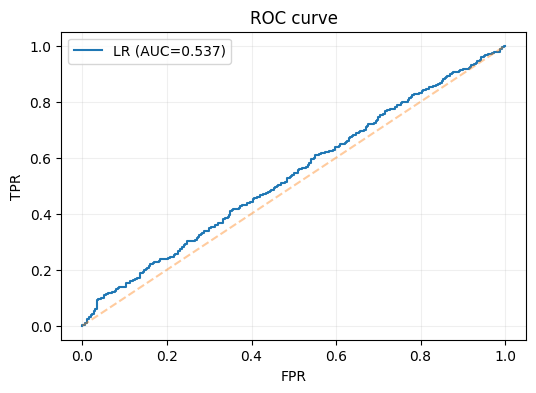

In [6]:
# Logistic Regression (with/without SMOTE) + RandomizedSearchCV

# helper: build a pipeline optionally with SMOTE
def make_lr_pipeline(use_smote=False):
    if use_smote:
        pipe = ImbPipeline(steps=[
            ('preprocess', preprocess),
            ('smote', SMOTE(random_state=RANDOM_SEED)),
            ('clf', LogisticRegression(max_iter=300, class_weight='balanced', random_state=RANDOM_SEED))
        ])
    else:
        pipe = Pipeline(steps=[
            ('preprocess', preprocess),
            ('clf', LogisticRegression(max_iter=300, class_weight='balanced', random_state=RANDOM_SEED))
        ])
    return pipe

lr_param_dist = {
    'clf__C': np.logspace(-2, 1, 10),   # 0.01..10
    'clf__penalty': ['l2'],             # lbfgs supports l2
    'clf__solver': ['lbfgs'],
}

# run both variants (no-SMOTE and SMOTE)
lr_best = {}
for tag, use_smote in [('LR', False), ('LR+SMOTE', True)]:
    lr_pipe = make_lr_pipeline(use_smote)
    lr_cv = RandomizedSearchCV(
        lr_pipe, lr_param_dist, n_iter=12,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        scoring='f1', random_state=RANDOM_SEED, n_jobs=-1, verbose=0
    )
    lr_cv.fit(X_train, y_train)
    lr_metrics, lr_proba, lr_pred = evaluate_clf(tag, lr_cv.best_estimator_, X_test, y_test)
    lr_best[tag] = (lr_cv.best_estimator_, lr_metrics, lr_proba)

# pick better of the two by F1
best_lr_name = max(lr_best.keys(), key=lambda k: lr_best[k][1]['f1'])
best_lr_pipe, best_lr_metrics, best_lr_proba = lr_best[best_lr_name]
print(f"Best LR variant: {best_lr_name}  ->  F1={best_lr_metrics['f1']:.4f}, ROC-AUC={best_lr_metrics.get('roc_auc',np.nan):.4f}")

# ROC plot
if best_lr_proba is not None:
    plot_roc_pr(best_lr_name, y_test, best_lr_proba)


In [ ]:
# Random Forest (with/without SMOTE) + RandomizedSearchCV

def make_rf_pipeline(use_smote=False):
    if use_smote:
        pipe = ImbPipeline(steps=[
            ('preprocess', preprocess),
            ('smote', SMOTE(random_state=RANDOM_SEED)),
            ('clf', RandomForestClassifier(random_state=RANDOM_SEED, class_weight='balanced'))
        ])
    else:
        pipe = Pipeline(steps=[
            ('preprocess', preprocess),
            ('clf', RandomForestClassifier(random_state=RANDOM_SEED, class_weight='balanced'))
        ])
    return pipe

rf_param_dist = {
    'clf__n_estimators': [200, 300, 400, 500],
    'clf__max_depth': [None, 8, 12, 16],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2', None],
}

rf_best = {}
for tag, use_smote in [('RF', False), ('RF+SMOTE', True)]:
    rf_pipe = make_rf_pipeline(use_smote)
    rf_cv = RandomizedSearchCV(
        rf_pipe, rf_param_dist, n_iter=20,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        scoring='f1', random_state=RANDOM_SEED, n_jobs=-1, verbose=0
    )
    rf_cv.fit(X_train, y_train)
    rf_metrics, rf_proba, rf_pred = evaluate_clf(tag, rf_cv.best_estimator_, X_test, y_test)
    rf_best[tag] = (rf_cv.best_estimator_, rf_metrics, rf_proba)

best_rf_name = max(rf_best.keys(), key=lambda k: rf_best[k][1]['f1'])
best_rf_pipe, best_rf_metrics, best_rf_proba = rf_best[best_rf_name]
print(f"Best RF variant: {best_rf_name}  ->  F1={best_rf_metrics['f1']:.4f}, ROC-AUC={best_rf_metrics.get('roc_auc',np.nan):.4f}")

if best_rf_proba is not None:
    plot_roc_pr(best_rf_name, y_test, best_rf_proba)


In [ ]:
#  XGBoost (with/without SMOTE) + RandomizedSearchCV

xgb_best = {}
try:
    def make_xgb_pipeline(use_smote=False):
        if use_smote:
            pipe = ImbPipeline(steps=[
                ('preprocess', preprocess),
                ('smote', SMOTE(random_state=RANDOM_SEED)),
                ('clf', XGBClassifier(
                    objective='binary:logistic', eval_metric='logloss',
                    tree_method='hist', random_state=RANDOM_SEED
                ))
            ])
        else:
            pipe = Pipeline(steps=[
                ('preprocess', preprocess),
                ('clf', XGBClassifier(
                    objective='binary:logistic', eval_metric='logloss',
                    tree_method='hist', random_state=RANDOM_SEED
                ))
            ])
        return pipe

    xgb_param_dist = {
        'clf__n_estimators': [300, 500, 700],
        'clf__max_depth': [4, 6, 8],
        'clf__learning_rate': [0.03, 0.05, 0.1],
        'clf__subsample': [0.8, 1.0],
        'clf__colsample_bytree': [0.8, 1.0],
    }

    for tag, use_smote in [('XGB', False), ('XGB+SMOTE', True)]:
        xgb_pipe = make_xgb_pipeline(use_smote)
        xgb_cv = RandomizedSearchCV(
            xgb_pipe, xgb_param_dist, n_iter=20,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
            scoring='f1', random_state=RANDOM_SEED, n_jobs=-1, verbose=0
        )
        xgb_cv.fit(X_train, y_train)
        xgb_metrics, xgb_proba, xgb_pred = evaluate_clf(tag, xgb_cv.best_estimator_, X_test, y_test)
        xgb_best[tag] = (xgb_cv.best_estimator_, xgb_metrics, xgb_proba)

    best_xgb_name = max(xgb_best.keys(), key=lambda k: xgb_best[k][1]['f1'])
    best_xgb_pipe, best_xgb_metrics, best_xgb_proba = xgb_best[best_xgb_name]
    print(f"Best XGB variant: {best_xgb_name}  ->  F1={best_xgb_metrics['f1']:.4f}, ROC-AUC={best_xgb_metrics.get('roc_auc',np.nan):.4f}")

    if best_xgb_proba is not None:
        plot_roc_pr(best_xgb_name, y_test, best_xgb_proba)

except Exception as e:
    print("XGBoost step skipped (package may not be installed or runtime issue):", e)
    best_xgb_name = None
    best_xgb_pipe = None
    best_xgb_metrics = {"f1": -1}
    best_xgb_proba = None


In [ ]:
# Compare models & tune decision threshold on the winner
rows = [
    best_lr_metrics | {"name": best_lr_name},
    best_rf_metrics | {"name": best_rf_name},
]
if best_xgb_pipe is not None:
    rows.append(best_xgb_metrics | {"name": best_xgb_name})

cmp_df = pd.DataFrame(rows).sort_values('f1', ascending=False).reset_index(drop=True)
display(cmp_df[['name','f1','precision','recall','accuracy','roc_auc']])

winner_name = cmp_df.iloc[0]['name']
if winner_name == best_lr_name:
    winner_pipe, winner_proba = best_lr_pipe, best_lr_proba
elif winner_name == best_rf_name:
    winner_pipe, winner_proba = best_rf_pipe, best_rf_proba
else:
    winner_pipe, winner_proba = best_xgb_pipe, best_xgb_proba

# threshold sweep for best F1
thr_df, best_thr, thr_row = sweep_thresholds(y_test, winner_proba, metric='f1')
print(f"Best threshold for {winner_name} by F1:", round(best_thr, 3))
display(thr_df.sort_values('f1', ascending=False).head(10))

# evaluate at tuned threshold
_ = evaluate_clf(f"{winner_name} (tuned)", winner_pipe, X_test, y_test, threshold=best_thr)


In [ ]:
# Confusion Matrix for the best model (tuned threshold)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict again at the tuned threshold
y_pred_tuned = (winner_proba >= best_thr).astype(int)
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Abandonment','Abandoned'])

# Plot in Colab
disp.plot(cmap='Blues', values_format='d')
plt.title(f'{winner_name} — Confusion Matrix (threshold={best_thr:.2f})')
plt.grid(False)
plt.show()

# Optional: print numeric details
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}")
print(f"Accuracy: {(tp+tn)/(tp+tn+fp+fn):.3f}")
print(f"Precision: {tp/(tp+fp):.3f}")
print(f"Recall: {tp/(tp+fn):.3f}")


In [ ]:
# Explainability (Permutation Importance)
# Get fitted preprocess from the winning pipeline
prep = winner_pipe.named_steps['preprocess']

# feature names after OHE + scaling
ohe = prep.named_transformers_['cat'].named_steps['ohe']
num_names = prep.named_transformers_['num'].named_steps['impute'].get_feature_names_out(num_cols) if hasattr(
    prep.named_transformers_['num'].named_steps['impute'], 'get_feature_names_out'
) else num_cols
cat_names = ohe.get_feature_names_out(cat_cols)
all_feature_names = list(num_names) + list(cat_names)

# transformed X for permutation importance
X_test_t = prep.transform(X_test)

# underlying classifier
clf = winner_pipe.named_steps['clf']

perm = permutation_importance(
    clf, X_test_t, y_test, n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1
)
pi = (pd.DataFrame({
    'feature': all_feature_names,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False))

display(pi.head(20))

# quick bar plot (top 20)
topk = pi.head(20).iloc[::-1]
plt.barh(topk['feature'], topk['importance_mean'])
plt.title(f"{winner_name} — Permutation Importance (top 20)")
plt.grid(True, axis='x', alpha=0.2)
plt.show()


In [ ]:
# Save the winning pipeline & threshold
import os

ARTIFACT_DIR = '/content/drive/MyDrive/42048/artifacts_cart_abandonment'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

model_path = f"{ARTIFACT_DIR}/{winner_name.replace('+','_')}_pipeline.joblib"
meta_path  = f"{ARTIFACT_DIR}/{winner_name.replace('+','_')}_meta.json"

joblib.dump(winner_pipe, model_path)

meta = {
    "winner_name": winner_name,
    "best_threshold": float(best_thr),
    "metrics_at_0_5": cmp_df.loc[cmp_df['name']==winner_name].iloc[0].to_dict(),
}
import json
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print("Saved model to:", model_path)
print("Saved meta  to:", meta_path)
